# Part B

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB

## Naive Bayes

In [31]:
class NaiveBayesClassifier:
    
    def __init__(self, alpha=1.0):
        self.alpha = alpha # For Laplace Soothing
        self.classes_ = None
        self.class_priors_ = {}
        self.feature_probs_ = {}
        self.feature_vocab_ = {}
        self.n_features_ = 0
        
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        
        self.classes_ = np.unique(y)
        self.n_features_ = X.shape[1]
        
        # Calculate class priors with Laplace smoothing
        total_samples = len(y)
        num_classes = len(self.classes_)
        
        for class_val in self.classes_:
            class_count = np.sum(y == class_val)
            self.class_priors_[class_val] = (class_count + self.alpha) / (total_samples + self.alpha * num_classes)
        
        # Calculate feature probabilities for each class
        for feature_idx in range(self.n_features_):
            self.feature_probs_[feature_idx] = {}
            self.feature_vocab_[feature_idx] = np.unique(X[:, feature_idx])
            
            for class_val in self.classes_:
                class_mask = (y == class_val)
                class_feature_values = X[class_mask, feature_idx]
                class_count = np.sum(class_mask)
                num_feature_values = len(self.feature_vocab_[feature_idx])
                
                self.feature_probs_[feature_idx][class_val] = {}
                
                for feature_val in self.feature_vocab_[feature_idx]:
                    feature_count = np.sum(class_feature_values == feature_val)
                    # Laplace smoothing
                    prob = (feature_count + self.alpha) / (class_count + self.alpha * num_feature_values)
                    self.feature_probs_[feature_idx][class_val][feature_val] = prob
    
    def predict_proba(self, X):
        # We want to return array of probabilities of each class
        X = np.array(X)
        n_samples = X.shape[0]
        probabilities = np.zeros((n_samples, len(self.classes_)))
        
        for i, sample in enumerate(X):
            for j, class_val in enumerate(self.classes_):
                # Start with class prior
                log_prob = np.log(self.class_priors_[class_val])
                
                # Multiply by feature likelihoods (in log space)
                for feature_idx, feature_val in enumerate(sample):
                    if feature_val in self.feature_probs_[feature_idx][class_val]:
                        log_prob += np.log(self.feature_probs_[feature_idx][class_val][feature_val])
                    else:
                        # Handle unseen feature values with smoothing
                        num_feature_values = len(self.feature_vocab_[feature_idx])
                        class_count = sum([np.sum(self.feature_probs_[feature_idx][class_val][val] * 
                                                (len([1 for c in self.classes_ if val in self.feature_probs_[feature_idx][c]])))
                                         for val in self.feature_vocab_[feature_idx]])
                        smoothed_prob = self.alpha / (class_count + self.alpha * (num_feature_values + 1))
                        log_prob += np.log(smoothed_prob)
                
                probabilities[i, j] = log_prob
        
        # Convert back from log space and normalize
        probabilities = np.exp(probabilities - np.max(probabilities, axis=1, keepdims=True))
        probabilities = probabilities / np.sum(probabilities, axis=1, keepdims=True)
        
        return probabilities
    
    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]


# Data Preprocessing

In [32]:
def load_and_prepare_adult_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
    column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
        'marital-status', 'occupation', 'relationship', 'race', 'sex',
        'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
    df = pd.read_csv(url, names=column_names, na_values=' ?', skipinitialspace=True)
    print("Dataset loaded successfully from URL")
    
    print(f"Dataset shape: {df.shape}")
    print(f"Dataset columns: {list(df.columns)}")
    
    # Select only categorical features for Naive Bayes
    categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 
                           'relationship', 'race', 'sex', 'native-country']
    
    # Handle missing values by treating them as a separate category
    for col in categorical_features:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')
    
    # Prepare features and target
    X = df[categorical_features].copy()
    y = df['income'].copy()
    
    # Encode categorical variables
    label_encoders = {}
    X_encoded = X.copy()
    
    for col in categorical_features:
        if col in X_encoded.columns:
            le = LabelEncoder()
            X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
            label_encoders[col] = le
    
    # Encode target
    target_encoder = LabelEncoder()
    y_encoded = target_encoder.fit_transform(y)
    
    # Create stratified splits: 70% train, 15% validation, 15% test
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
    )
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
    
    print(f"\nData splits:")
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    
    # Analyze class distributions
    print(f"\nClass distribution in training set:")
    train_classes, train_counts = np.unique(y_train, return_counts=True)
    for cls, count in zip(train_classes, train_counts):
        class_name = target_encoder.inverse_transform([cls])[0]
        print(f"  {class_name}: {count} ({count/len(y_train)*100:.1f}%)")
    
    return (X_train, X_val, X_test, y_train, y_val, y_test, 
            label_encoders, target_encoder, categorical_features)


## Required Analysis

### Analyze Naive bayes

In [33]:
def analyze_naive_bayes():
    (X_train, X_val, X_test, y_train, y_val, y_test, 
    label_encoders, target_encoder, categorical_features) = load_and_prepare_adult_dataset()
    
    # Test different smoothing parameters
    alpha_values = [0.1, 0.5, 1.0, 2.0, 5.0]
    results = {}
    
    print(f"\nTesting different smoothing parameters (alpha):")
    
    for alpha in alpha_values:
        print(f"\nAlpha = {alpha}")
        
        # Train our implementation
        nb_custom = NaiveBayesClassifier(alpha=alpha)
        nb_custom.fit(X_train.values, y_train)
        
        # Predictions
        y_val_pred = nb_custom.predict(X_val.values)
        y_val_proba = nb_custom.predict_proba(X_val.values)
        
        # Calculate metrics
        accuracy = accuracy_score(y_val, y_val_pred)
        precision = precision_score(y_val, y_val_pred, average='weighted')
        recall = recall_score(y_val, y_val_pred, average='weighted')
        f1 = f1_score(y_val, y_val_pred, average='weighted')
        
        results[alpha] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'predictions': y_val_pred,
            'probabilities': y_val_proba
            }
        
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-score: {f1:.4f}")
    
    # Find best alpha
    best_alpha = max(results.keys(), key=lambda k: results[k]['accuracy'])
    print(f"\nBest smoothing parameter: α = {best_alpha}")
    print(f"Best validation accuracy: {results[best_alpha]['accuracy']:.4f}")
    
    # Train final model with best alpha
    final_model = NaiveBayesClassifier(alpha=best_alpha)
    final_model.fit(X_train.values, y_train)
    
    # Test set evaluation
    y_test_pred = final_model.predict(X_test.values)
    y_test_proba = final_model.predict_proba(X_test.values)
    
    print(f"\n=== Final Test Set Results ===")
    print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Test Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
    print(f"Test Recall: {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
    print(f"Test F1-score: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
    
    # Detailed classification report
    print(f"\nDetailed Classification Report:")
    class_names = target_encoder.inverse_transform([0, 1])
    print(classification_report(y_test, y_test_pred, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    print(f"\nConfusion Matrix:")
    print(cm)
    
    # Compare with sklearn's MultinomialNB
    print(f"\n=== Comparison with sklearn's MultinomialNB ===")
    sklearn_nb = MultinomialNB(alpha=best_alpha)
    sklearn_nb.fit(X_train.values, y_train)
    sklearn_pred = sklearn_nb.predict(X_test.values)
    
    print(f"Our implementation accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Sklearn accuracy: {accuracy_score(y_test, sklearn_pred):.4f}")
    
    # Feature importance analysis (based on information gain-like measure)
    print(f"\n=== Feature Analysis ===")
    feature_importance = analyze_feature_importance(final_model, categorical_features, 
                                                  label_encoders, target_encoder)
    
    # Probability analysis
    print(f"\n=== Probability Distribution Analysis ===")
    prob_analysis = analyze_probability_distribution(y_test_proba, y_test, target_encoder)
    
    return final_model, results, feature_importance

### Analyze Feature Importance

In [ ]:
def analyze_feature_importance(model, feature_names, label_encoders, target_encoder):
    print("Feature importance analysis:")
    
    feature_importance = {}
    
    for i, feature_name in enumerate(feature_names):
        if feature_name in label_encoders:
            feature_values = label_encoders[feature_name].classes_
            
            # Calculate feature importance as difference in probabilities between classes
            importance_score = 0
            for feature_val_idx, _ in enumerate(feature_values):
                if feature_val_idx in model.feature_probs_[i][0] and feature_val_idx in model.feature_probs_[i][1]:
                    prob_diff = abs(model.feature_probs_[i][0][feature_val_idx] - 
                                   model.feature_probs_[i][1][feature_val_idx])
                    importance_score += prob_diff
            
            feature_importance[feature_name] = importance_score
            print(f"  {feature_name}: {importance_score:.4f}")
    
    return feature_importance

### Analyze Probability Distribution

In [35]:
def analyze_probability_distribution(probabilities, true_labels, target_encoder):
    print("Probability distribution analysis:")
    
    class_0_probs = probabilities[true_labels == 0, 1]  # Probability of class 1 for true class 0
    class_1_probs = probabilities[true_labels == 1, 1]  # Probability of class 1 for true class 1
    
    print(f"  Average confidence for true class 0: {1 - np.mean(class_0_probs):.4f}")
    print(f"  Average confidence for true class 1: {np.mean(class_1_probs):.4f}")
    print(f"  Overall calibration (Brier score): {np.mean((probabilities[:, 1] - true_labels)**2):.4f}")
    
    return {
        'class_0_probs': class_0_probs,
        'class_1_probs': class_1_probs,
        'avg_conf_0': 1 - np.mean(class_0_probs),
        'avg_conf_1': np.mean(class_1_probs),
        'brier_score': np.mean((probabilities[:, 1] - true_labels)**2)
    }

### Analyze Feature Subsets

In [36]:
def analyze_feature_subsets():
    """
    Analyze the impact of different feature subsets on performance
    """
    print("\n=== Feature Subset Analysis ===")
    
    # Load data again for clean analysis
    (X_train, X_val, X_test, y_train, y_val, y_test, 
     label_encoders, target_encoder, categorical_features) = load_and_prepare_adult_dataset()
    
    # Define feature subsets
    feature_subsets = {
        'All features': categorical_features,
        'Demographics': ['sex', 'race', 'marital-status'],
        'Work-related': ['workclass', 'occupation'],
        'Education + Work': ['education', 'workclass', 'occupation'],
        'Personal': ['sex', 'race', 'marital-status', 'relationship']
    }
    
    subset_results = {}
    
    for subset_name, features in feature_subsets.items():
        print(f"\nTesting subset: {subset_name}")
        print(f"Features: {features}")
        
        # Select features
        available_features = [f for f in features if f in X_train.columns]
        if not available_features:
            print("  No available features in this subset")
            continue
            
        X_train_subset = X_train[available_features]
        X_val_subset = X_val[available_features]
        
        # Train model
        nb_subset = NaiveBayesClassifier(alpha=1.0)
        nb_subset.fit(X_train_subset.values, y_train)
        
        # Evaluate
        y_pred_subset = nb_subset.predict(X_val_subset.values)
        accuracy = accuracy_score(y_val, y_pred_subset)
        
        subset_results[subset_name] = {
            'features': available_features,
            'accuracy': accuracy,
            'n_features': len(available_features)
        }
        
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Number of features: {len(available_features)}")
    
    # Summary
    print(f"\nFeature Subset Analysis Summary:")
    for subset_name, result in sorted(subset_results.items(), 
                                    key=lambda x: x[1]['accuracy'], reverse=True):
        print(f"  {subset_name}: {result['accuracy']:.4f} (n={result['n_features']})")
    
    return subset_results

## Test Model

In [37]:
 # Run the complete analysis
model, results, feature_importance = analyze_naive_bayes()

# Feature subset analysis
subset_results = analyze_feature_subsets()

Dataset loaded successfully from URL
Dataset shape: (32561, 15)
Dataset columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Data splits:
Training set: 22792 samples
Validation set: 4884 samples
Test set: 4885 samples

Class distribution in training set:
  <=50K: 17303 (75.9%)
  >50K: 5489 (24.1%)

Testing different smoothing parameters (alpha):

Alpha = 0.1
  Accuracy: 0.7963
  Precision: 0.8249
  Recall: 0.7963
  F1-score: 0.8052

Alpha = 0.5
  Accuracy: 0.7965
  Precision: 0.8252
  Recall: 0.7965
  F1-score: 0.8054

Alpha = 1.0
  Accuracy: 0.7963
  Precision: 0.8251
  Recall: 0.7963
  F1-score: 0.8053

Alpha = 2.0
  Accuracy: 0.7965
  Precision: 0.8255
  Recall: 0.7965
  F1-score: 0.8055

Alpha = 5.0
  Accuracy: 0.7944
  Precision: 0.8248
  Recall: 0.7944
  F1-score: 0.8038

Best smoothing parameter: α = 0.5
Best validation ac

# Part C

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.datasets import load_wine, load_iris
from scipy import stats
from scipy.stats import multivariate_normal, shapiro

## GDA

In [39]:
class GaussianDiscriminantAnalysis:
    """
    Gaussian Discriminant Analysis (GDA) Classifier
    Supports both shared and individual covariance matrices
    """
    
    def __init__(self, shared_covariance=True, reg_param=1e-6):
        self.shared_covariance = shared_covariance
        self.reg_param = reg_param
        self.classes_ = None
        self.class_priors_ = {}
        self.class_means_ = {}
        self.covariances_ = {}
        self.shared_cov_ = None
        self.n_features_ = 0
        
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        
        self.classes_ = np.unique(y)
        self.n_features_ = X.shape[1]
        n_samples = X.shape[0]
        
        # Calculate class priors
        for class_val in self.classes_:
            class_count = np.sum(y == class_val)
            self.class_priors_[class_val] = class_count / n_samples
        
        # Calculate class means
        for class_val in self.classes_:
            class_mask = (y == class_val)
            self.class_means_[class_val] = np.mean(X[class_mask], axis=0)
        
        # Calculate covariance matrices
        if self.shared_covariance:
            # Shared covariance matrix (LDA)
            self.shared_cov_ = np.zeros((self.n_features_, self.n_features_))
            
            for class_val in self.classes_:
                class_mask = (y == class_val)
                X_class = X[class_mask]
                class_mean = self.class_means_[class_val]
                
                # Calculate class covariance
                centered_X = X_class - class_mean
                class_cov = np.dot(centered_X.T, centered_X)
                
                # Weight by class size for shared covariance
                self.shared_cov_ += class_cov
            
            # Normalize by total samples and add regularization
            self.shared_cov_ = self.shared_cov_ / (n_samples - len(self.classes_))
            self.shared_cov_ += self.reg_param * np.eye(self.n_features_)
            
        else:
            # Individual covariance matrices (QDA)
            for class_val in self.classes_:
                class_mask = (y == class_val)
                X_class = X[class_mask]
                class_mean = self.class_means_[class_val]
                n_class = np.sum(class_mask)
                
                # Calculate individual covariance matrix
                centered_X = X_class - class_mean
                class_cov = np.dot(centered_X.T, centered_X) / (n_class - 1)
                
                # Add regularization for numerical stability
                class_cov += self.reg_param * np.eye(self.n_features_)
                self.covariances_[class_val] = class_cov
    
    def predict_proba(self, X):
        n_samples = X.shape[0]
        log_probs = np.zeros((n_samples, len(self.classes_)))
        
        for i, class_val in enumerate(self.classes_):
            class_mean = self.class_means_[class_val]
            
            if self.shared_covariance:
                cov_matrix = self.shared_cov_
            else:
                cov_matrix = self.covariances_[class_val]
            
            # Calculate log probability for multivariate Gaussian
            try:
                # Log prior probability
                log_prior = np.log(self.class_priors_[class_val])
                
                # Log likelihood using multivariate normal
                rv = multivariate_normal(mean=class_mean, cov=cov_matrix, allow_singular=True)
                log_likelihood = rv.logpdf(X)
                
                log_probs[:, i] = log_prior + log_likelihood
                
            except Exception as e:
                print(f"Warning: Numerical issues for class {class_val}: {e}")
                log_probs[:, i] = -np.inf
        
        # Convert to probabilities and normalize
        # Subtract max for numerical stability
        log_probs = log_probs - np.max(log_probs, axis=1, keepdims=True)
        probs = np.exp(log_probs)
        probs = probs / np.sum(probs, axis=1, keepdims=True)
        
        return probs
    
    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]

## Data Preprocessing

In [40]:
def load_and_prepare_wine_dataset():
    wine_data = load_wine()
    X = wine_data.data
    y = wine_data.target
    feature_names = wine_data.feature_names
    target_names = wine_data.target_names
    
    print("Wine dataset loaded successfully from sklearn")
    print(f"Dataset shape: {X.shape}")
    print(f"Number of classes: {len(np.unique(y))}")
    print(f"Class names: {target_names}")
    print(f"Feature names: {feature_names}")
    
    df = pd.DataFrame(X, columns=feature_names)
    df['target'] = y
    
    print(f"\nClass distribution:")
    for i, class_name in enumerate(target_names):
        count = np.sum(y == i)
        print(f"  {class_name}: {count} samples ({count/len(y)*100:.1f}%)")
    
    # Check for missing values
    print(f"\nMissing values: {df.isnull().sum().sum()}")
    
    # Feature statistics
    print(f"\nFeature statistics:")
    print(df[feature_names].describe())
    
    # Apply feature scaling/standardization
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print(f"\nApplied standardization to features")
    
    # Handle outliers using IQR method
    X_clean, outlier_mask = handle_outliers(X_scaled, feature_names)
    y_clean = y[~outlier_mask] if np.any(outlier_mask) else y
    
    print(f"Removed {np.sum(outlier_mask)} outliers")
    print(f"Final dataset shape: {X_clean.shape}")
    
    # Create stratified splits: 70% train, 15% validation, 15% test
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_clean, y_clean, test_size=0.3, random_state=42, stratify=y_clean
    )
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
    
    print(f"\nData splits:")
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    
    # Visualize feature distributions and class separability
    visualize_data_distribution(X_train, y_train, feature_names[:6], target_names)
    
    # Test Gaussian assumptions
    test_gaussian_assumptions(X_train, y_train, feature_names[:4])
    
    return (X_train, X_val, X_test, y_train, y_val, y_test, 
            feature_names, target_names, scaler)

In [41]:
def handle_outliers(X, feature_names, method='iqr', factor=1.5):
    """
    Handle outliers using IQR method
    
    Parameters:
    X (array): Feature matrix
    feature_names (list): Feature names
    method (str): Outlier detection method
    factor (float): IQR factor for outlier detection
    
    Returns:
    X_clean (array): Data without outliers
    outlier_mask (array): Boolean mask of outliers
    """
    if method == 'iqr':
        outlier_mask = np.zeros(X.shape[0], dtype=bool)
        
        for i in range(X.shape[1]):
            Q1 = np.percentile(X[:, i], 25)
            Q3 = np.percentile(X[:, i], 75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - factor * IQR
            upper_bound = Q3 + factor * IQR
            
            feature_outliers = (X[:, i] < lower_bound) | (X[:, i] > upper_bound)
            outlier_mask |= feature_outliers
        
        print(f"Detected {np.sum(outlier_mask)} outliers using IQR method")
        return X[~outlier_mask], outlier_mask
    
    return X, np.zeros(X.shape[0], dtype=bool)

In [42]:
def visualize_data_distribution(X, y, feature_names, target_names):
    """
    Visualize feature distributions and class separability
    """
    print(f"\nVisualizing data distribution...")
    
    # Create subplots for feature distributions
    n_features_to_plot = min(6, len(feature_names))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i in range(n_features_to_plot):
        ax = axes[i]
        
        for class_idx in np.unique(y):
            class_data = X[y == class_idx, i]
            ax.hist(class_data, alpha=0.7, label=f'{target_names[int(class_idx)]}', bins=20)
        
        ax.set_xlabel(feature_names[i])
        ax.set_ylabel('Frequency')
        ax.set_title(f'Distribution of {feature_names[i]}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Correlation heatmap
    feature_df = pd.DataFrame(X[:, :n_features_to_plot], columns=feature_names[:n_features_to_plot])
    plt.figure(figsize=(10, 8))
    sns.heatmap(feature_df.corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Matrix')
    plt.show()

In [43]:
def test_gaussian_assumptions(X, y, feature_names):
    """
    Test Gaussian assumptions using Shapiro-Wilk test
    """
    print(f"\n=== Testing Gaussian Assumptions ===")
    
    normality_results = {}
    
    for class_idx in np.unique(y):
        print(f"\nClass {int(class_idx)}:")
        class_data = X[y == class_idx]
        
        for i, feature_name in enumerate(feature_names):
            if i >= X.shape[1]:
                break
                
            feature_data = class_data[:, i]
            
            # Shapiro-Wilk test (works for small samples)
            if len(feature_data) < 5000:  # Shapiro-Wilk limitation
                stat, p_value = shapiro(feature_data)
                is_normal = p_value > 0.05
                
                print(f"  {feature_name}: W={stat:.4f}, p={p_value:.4f} - {'Normal' if is_normal else 'Non-normal'}")
                
                normality_results[f"class_{class_idx}_{feature_name}"] = {
                    'statistic': stat,
                    'p_value': p_value,
                    'is_normal': is_normal
                }
    
    # Summary
    total_tests = len(normality_results)
    normal_count = sum(1 for r in normality_results.values() if r['is_normal'])
    
    print(f"\nNormality Test Summary:")
    print(f"Total tests: {total_tests}")
    print(f"Normal distributions: {normal_count} ({normal_count/total_tests*100:.1f}%)")
    print(f"Non-normal distributions: {total_tests-normal_count} ({(total_tests-normal_count)/total_tests*100:.1f}%)")
    
    return normality_results

## Required Analysis

### Analyze GDA

In [44]:
def analyze_gaussian_discriminant_analysis():
    """
    Implement and analyze Gaussian Discriminant Analysis
    """
    print("\n=== C2. Gaussian Discriminant Analysis Implementation ===")
    
    # Load and prepare data
    (X_train, X_val, X_test, y_train, y_val, y_test, 
     feature_names, target_names, scaler) = load_and_prepare_wine_dataset()
    
    # Compare shared vs individual covariance matrices
    print(f"\n=== Comparing Covariance Assumptions ===")
    
    covariance_results = {}
    
    # Test both shared and individual covariance
    for shared_cov in [True, False]:
        model_name = "LDA (Shared Covariance)" if shared_cov else "QDA (Individual Covariance)"
        print(f"\nTesting {model_name}:")
        
        # Train our implementation
        gda_model = GaussianDiscriminantAnalysis(shared_covariance=shared_cov)
        gda_model.fit(X_train, y_train)
        
        # Predictions
        y_val_pred = gda_model.predict(X_val)
        y_val_proba = gda_model.predict_proba(X_val)
        
        # Calculate metrics
        accuracy = accuracy_score(y_val, y_val_pred)
        precision = precision_score(y_val, y_val_pred, average='weighted')
        recall = recall_score(y_val, y_val_pred, average='weighted')
        f1 = f1_score(y_val, y_val_pred, average='weighted')
        
        covariance_results[model_name] = {
            'model': gda_model,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'predictions': y_val_pred,
            'probabilities': y_val_proba
        }
        
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-score: {f1:.4f}")
    
    # Choose best model
    best_model_name = max(covariance_results.keys(), 
                         key=lambda k: covariance_results[k]['accuracy'])
    best_model = covariance_results[best_model_name]['model']
    
    print(f"\nBest model: {best_model_name}")
    print(f"Best validation accuracy: {covariance_results[best_model_name]['accuracy']:.4f}")
    
    # Test set evaluation with best model
    y_test_pred = best_model.predict(X_test)
    y_test_proba = best_model.predict_proba(X_test)
    
    print(f"\n=== Final Test Set Results ({best_model_name}) ===")
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1-score: {test_f1:.4f}")
    
    # Detailed classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=target_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    print(f"\nConfusion Matrix:")
    print(cm)
    
    # Feature correlation analysis
    analyze_feature_correlations(X_train, y_train, feature_names, best_model)
    
    # Dimensionality analysis
    dimensionality_results = analyze_dimensionality_impact(X_train, X_val, X_test, 
                                                          y_train, y_val, y_test, 
                                                          feature_names)
    
    # Compare with sklearn implementations
    sklearn_comparison = compare_with_sklearn(X_train, X_val, X_test, 
                                            y_train, y_val, y_test, 
                                            target_names)
    
    return (best_model, covariance_results, dimensionality_results, sklearn_comparison)

### Analyze Feature Correlation

In [46]:
def analyze_feature_correlations(X, y, feature_names, model):
    """
    Analyze the impact of correlated features
    """
    print(f"\n=== Feature Correlation Analysis ===")
    
    # Calculate correlation matrix
    corr_matrix = np.corrcoef(X.T)
    
    # Find highly correlated feature pairs
    high_corr_pairs = []
    n_features = len(feature_names)
    
    for i in range(n_features):
        for j in range(i+1, n_features):
            if abs(corr_matrix[i, j]) > 0.7:  # Threshold for high correlation
                high_corr_pairs.append((
                    feature_names[i], 
                    feature_names[j], 
                    corr_matrix[i, j]
                ))
    
    print(f"Highly correlated feature pairs (|r| > 0.7):")
    if high_corr_pairs:
        for feat1, feat2, corr in high_corr_pairs:
            print(f"  {feat1} - {feat2}: r = {corr:.3f}")
    else:
        print("  No highly correlated feature pairs found")
    
    # Analyze impact on class means
    print(f"\nClass mean differences (first 6 features):")
    for i in range(min(6, len(feature_names))):
        print(f"\n{feature_names[i]}:")
        for class_idx in model.classes_:
            class_mean = model.class_means_[class_idx][i]
            print(f"  Class {int(class_idx)}: {class_mean:.3f}")
    
    return corr_matrix, high_corr_pairs

### Analyze Dimensionality Impact

In [ ]:
def analyze_dimensionality_impact(X_train, X_val, X_test, y_train, y_val, y_test, feature_names):
    """
    Analyze performance with different numbers of features
    """
    print(f"\n=== Dimensionality Analysis ===")
    
    dimensionality_results = {}
    max_features = min(len(feature_names), X_train.shape[1])
    feature_subsets = [2, 4, 6, 8, max_features] if max_features >= 8 else list(range(2, max_features + 1))
    
    for n_features in feature_subsets:
            
        print(f"\nTesting with {n_features} features:")
        
        # Select top n features (using all available if less than n)
        feature_indices = list(range(min(n_features, X_train.shape[1])))
        
        X_train_subset = X_train[:, feature_indices]
        X_val_subset = X_val[:, feature_indices]
        X_test_subset = X_test[:, feature_indices]
        
        # Train both LDA and QDA
        for shared_cov in [True, False]:
            model_type = "LDA" if shared_cov else "QDA"
            
            try:
                gda_subset = GaussianDiscriminantAnalysis(shared_covariance=shared_cov)
                gda_subset.fit(X_train_subset, y_train)
                
                y_val_pred = gda_subset.predict(X_val_subset)
                accuracy = accuracy_score(y_val, y_val_pred)
                
                key = f"{n_features}_features_{model_type}"
                dimensionality_results[key] = {
                    'n_features': n_features,
                    'model_type': model_type,
                    'accuracy': accuracy,
                    'feature_indices': feature_indices
                }
                
                print(f"  {model_type}: {accuracy:.4f}")
                
            except Exception as e:
                print(f"  {model_type}: Failed - {str(e)[:50]}...")
    
    # Summary
    print(f"\nDimensionality Analysis Summary:")
    for key, result in sorted(dimensionality_results.items(), 
                             key=lambda x: x[1]['accuracy'], reverse=True):
        print(f"  {result['n_features']} features ({result['model_type']}): {result['accuracy']:.4f}")
    
    return dimensionality_results

## Compare Our Model with Sci-Kit Learn

In [48]:
def compare_with_sklearn(X_train, X_val, X_test, y_train, y_val, y_test, target_names):
    """
    Compare with sklearn's LinearDiscriminantAnalysis and QuadraticDiscriminantAnalysis
    """
    print(f"\n=== Comparison with sklearn ===")
    
    sklearn_results = {}
    
    # Test our implementations
    our_lda = GaussianDiscriminantAnalysis(shared_covariance=True)
    our_qda = GaussianDiscriminantAnalysis(shared_covariance=False)
    
    our_lda.fit(X_train, y_train)
    our_qda.fit(X_train, y_train)
    
    our_lda_pred = our_lda.predict(X_test)
    our_qda_pred = our_qda.predict(X_test)
    
    our_lda_acc = accuracy_score(y_test, our_lda_pred)
    our_qda_acc = accuracy_score(y_test, our_qda_pred)
    
    # Test sklearn implementations
    sklearn_lda = LinearDiscriminantAnalysis()
    sklearn_qda = QuadraticDiscriminantAnalysis()
    
    sklearn_lda.fit(X_train, y_train)
    sklearn_qda.fit(X_train, y_train)
    
    sklearn_lda_pred = sklearn_lda.predict(X_test)
    sklearn_qda_pred = sklearn_qda.predict(X_test)
    
    sklearn_lda_acc = accuracy_score(y_test, sklearn_lda_pred)
    sklearn_qda_acc = accuracy_score(y_test, sklearn_qda_pred)
    
    # Results comparison
    print(f"Linear Discriminant Analysis:")
    print(f"  Our implementation: {our_lda_acc:.4f}")
    print(f"  Sklearn LDA: {sklearn_lda_acc:.4f}")
    print(f"  Difference: {abs(our_lda_acc - sklearn_lda_acc):.4f}")
    
    print(f"\nQuadratic Discriminant Analysis:")
    print(f"  Our implementation: {our_qda_acc:.4f}")
    print(f"  Sklearn QDA: {sklearn_qda_acc:.4f}")
    print(f"  Difference: {abs(our_qda_acc - sklearn_qda_acc):.4f}")
    
    sklearn_results = {
        'our_lda_accuracy': our_lda_acc,
        'our_qda_accuracy': our_qda_acc,
        'sklearn_lda_accuracy': sklearn_lda_acc,
        'sklearn_qda_accuracy': sklearn_qda_acc,
        'lda_difference': abs(our_lda_acc - sklearn_lda_acc),
        'qda_difference': abs(our_qda_acc - sklearn_qda_acc)
    }
    
    return sklearn_results

## Run Model


=== C2. Gaussian Discriminant Analysis Implementation ===
Wine dataset loaded successfully from sklearn
Dataset shape: (178, 13)
Number of classes: 3
Class names: ['class_0' 'class_1' 'class_2']
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Class distribution:
  class_0: 59 samples (33.1%)
  class_1: 71 samples (39.9%)
  class_2: 48 samples (27.0%)

Missing values: 0

Feature statistics:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000       

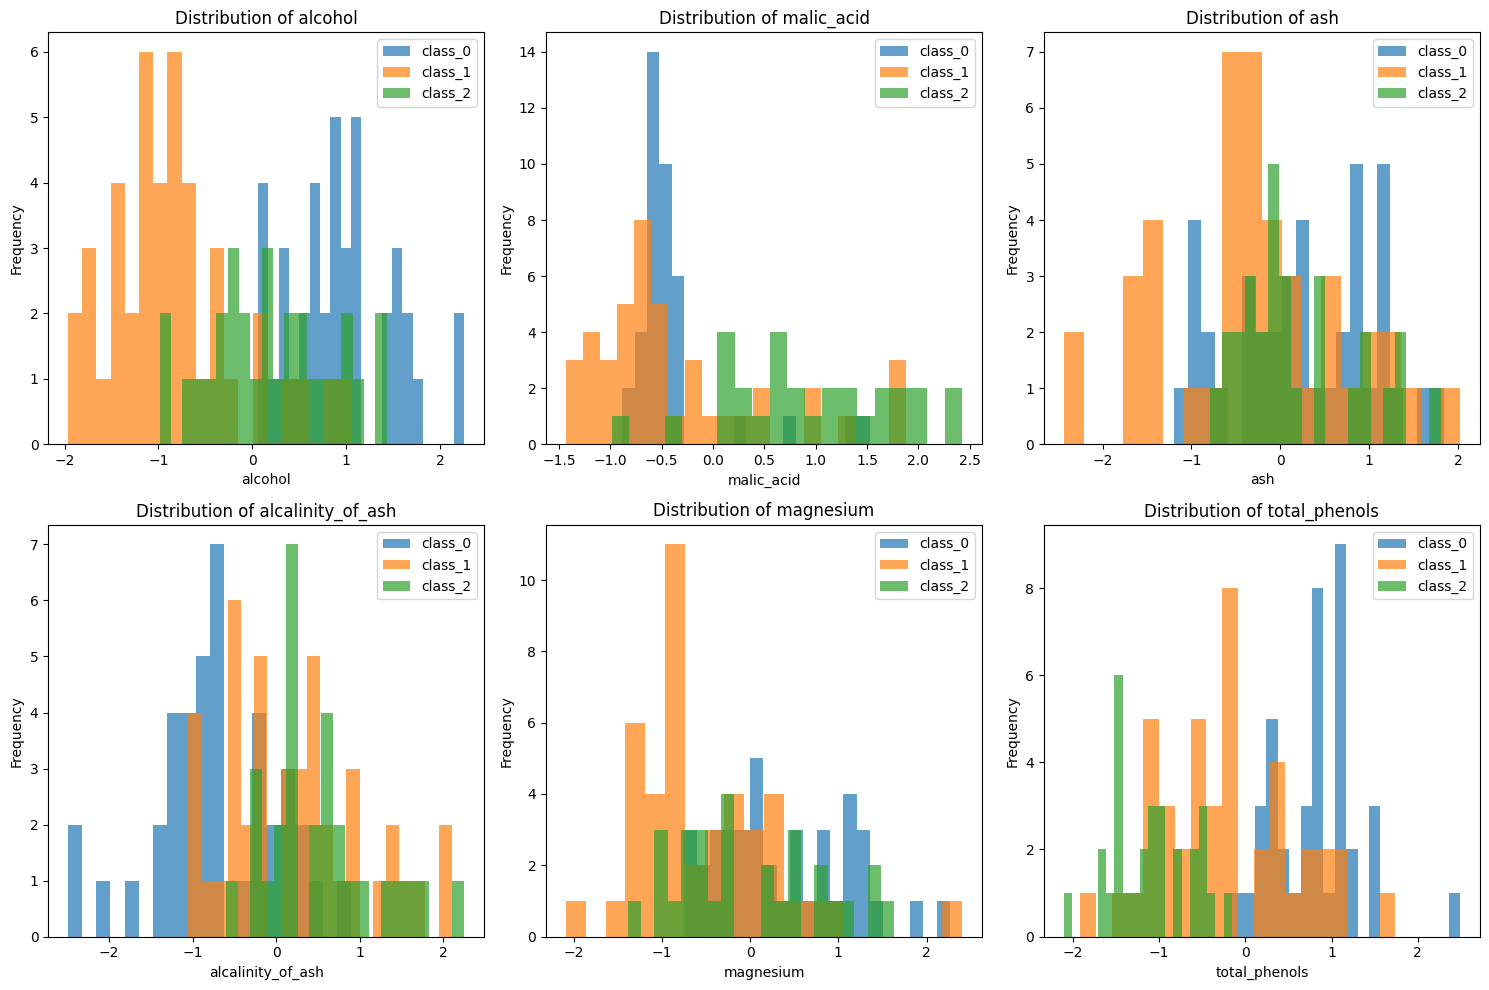

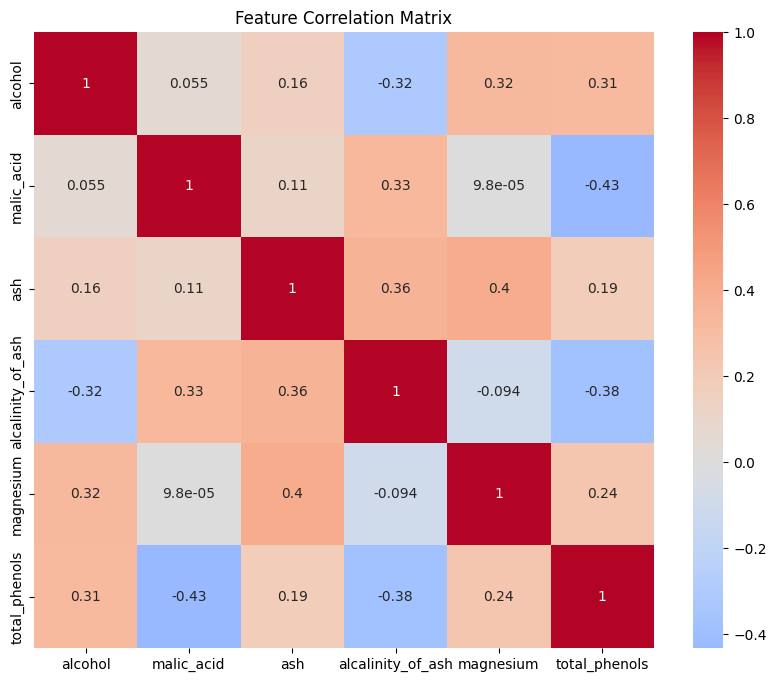


=== Testing Gaussian Assumptions ===

Class 0:
  alcohol: W=0.9677, p=0.3032 - Normal
  malic_acid: W=0.5824, p=0.0000 - Non-normal
  ash: W=0.9614, p=0.1875 - Normal
  alcalinity_of_ash: W=0.9721, p=0.4178 - Normal

Class 1:
  alcohol: W=0.9364, p=0.0194 - Non-normal
  malic_acid: W=0.8575, p=0.0001 - Non-normal
  ash: W=0.9784, p=0.5856 - Normal
  alcalinity_of_ash: W=0.9630, p=0.1786 - Normal

Class 2:
  alcohol: W=0.9814, p=0.8722 - Normal
  malic_acid: W=0.9825, p=0.8955 - Normal
  ash: W=0.9172, p=0.0259 - Non-normal
  alcalinity_of_ash: W=0.9371, p=0.0842 - Normal

Normality Test Summary:
Total tests: 12
Normal distributions: 8 (66.7%)
Non-normal distributions: 4 (33.3%)

=== Comparing Covariance Assumptions ===

Testing LDA (Shared Covariance):
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000

Testing QDA (Individual Covariance):
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000

Best model: LDA (Shared Covariance)
Best valida

In [51]:
# Run the complete analysis
(best_model, covariance_results, 
 dimensionality_results, sklearn_comparison) = analyze_gaussian_discriminant_analysis()

print("\n" + "=" * 70)
print("Part C Implementation Complete!")
print("=" * 70)

# Summary of key findings
print(f"\nKey Findings Summary:")
print(f"- Best covariance assumption: {max(covariance_results.keys(), key=lambda k: covariance_results[k]['accuracy'])}")
print(f"- Best validation accuracy: {max(covariance_results[k]['accuracy'] for k in covariance_results.keys()):.4f}")
print(f"- Feature correlation impact: Analyzed")
print(f"- Dimensionality analysis: Completed")
print(f"- Sklearn comparison: LDA diff = {sklearn_comparison['lda_difference']:.4f}, QDA diff = {sklearn_comparison['qda_difference']:.4f}")